#  Pruebas de Hipótesis — Relación de Variables con Attrition
## Dataset: Rotación de Empleados (IBM HR Analytics)



---

## Configuración general

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
from scipy.stats import (chi2_contingency, pearsonr, spearmanr,
                         kendalltau, f_oneway, kruskal, shapiro)
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import LabelEncoder

plt.rcParams.update({'figure.dpi': 120, 'axes.spines.top': False,
                     'axes.spines.right': False, 'font.size': 11})

# ── Carga y limpieza ──────────────────────────────────────────────────────────
DB_PATH = Path().resolve().parent / "data" / "raw" / "dataset_clasificacion.csv"

df = pd.read_csv(DB_PATH)
str_cols = df.select_dtypes(include='object').columns
for col in str_cols:
    df[col] = (df[col].astype(str).str.strip().str.lower()
               .str.replace(r'[^a-z0-9 _&\-]', '', regex=True))

# Variable objetivo codificada numéricamente (Yes=1, No=0)
df['Attrition_bin'] = (df['Attrition'] == 'yes').astype(int)

ALPHA = 0.05   # Nivel de significancia — confianza del 95 %

# ── Separar variables por tipo ────────────────────────────────────────────────
# Constantes y IDs excluidos del análisis
EXCLUIR = {'Attrition', 'Attrition_bin', 'EmployeeCount',
           'EmployeeNumber', 'StandardHours', 'Over18'}

CAT_VARS = [c for c in df.select_dtypes(include='object').columns
            if c not in EXCLUIR]

# Numéricas continuas: alta cardinalidad (> 10 valores únicos)
NUM_CONT = [c for c in df.select_dtypes(include=[np.number]).columns
            if c not in EXCLUIR and df[c].nunique() > 10]

# Numéricas ordinales: baja cardinalidad (≤ 10 valores únicos)
NUM_ORD = [c for c in df.select_dtypes(include=[np.number]).columns
           if c not in EXCLUIR and df[c].nunique() <= 10]

print("Variables categóricas  :", CAT_VARS)
print("Variables numéricas cont:", NUM_CONT)
print("Variables numéricas ord :", NUM_ORD)
print(f"\nAttrition Yes: {(df['Attrition_bin']==1).sum()}  |  No: {(df['Attrition_bin']==0).sum()}")

Variables categóricas  : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus', 'OverTime']
Variables numéricas cont: ['Age', 'DailyRate', 'DistanceFromHome', 'HourlyRate', 'MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']
Variables numéricas ord : ['Education', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'NumCompaniesWorked', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']

Attrition Yes: 237  |  No: 1233


### Función auxiliar de reporte

In [2]:
def reporte(var, prueba, stat, pval, rechaza, extra=''):
    decision = "✅ SE RECHAZA H₀" if rechaza else "❌ NO se rechaza H₀"
    simbolo  = "**" if rechaza else "  "
    print(f"{simbolo}{var:<30} [{prueba}]  stat={stat:>10.4f}  p={pval:.6f}  → {decision}{extra}")

---
## 1. Hipótesis de Prueba

Para cada variable se plantea la misma estructura de hipótesis:

> **H₀ (hipótesis nula):** La variable X es **independiente** de Attrition —  
> no existe asociación estadísticamente significativa entre ambas.
>
> **H₁ (hipótesis alternativa):** La variable X y Attrition **no son independientes** —  
> existe una asociación estadísticamente significativa.

**Criterio de decisión:** Si **p-valor < α = 0.05**, se rechaza H₀ con un 95 % de confianza,
concluyendo que la variable tiene una relación significativa con Attrition.

---
### Por qué usar cada prueba

**Chi-cuadrado:** Compara las frecuencias observadas en una tabla de contingencia con
las que se esperarían si las variables fueran independientes. Es la prueba estándar
para dos variables categóricas. Supone que ninguna celda tiene frecuencia esperada < 5.

**Mutual Information (MI):** Mide cuánta información comparte una variable con Attrition,
sin asumir linealidad ni distribución. Complementa Chi-cuadrado al cuantificar la
*magnitud* de la dependencia (no solo si existe). Un MI = 0 indica independencia total.

**Pearson:** Mide correlación lineal entre dos variables cuantitativas continuas.
Se usa cuando ambas son aproximadamente normales. Sensible a outliers.

**Spearman:** Mide correlación monótona usando rangos. No requiere normalidad y es
más robusta frente a outliers y distribuciones asimétricas. Adecuada para datos
ordinales o cuando Pearson falla el supuesto de normalidad.

**Kendall:** Mide concordancia de pares. Más conservadora que Spearman y preferible
cuando hay muchos empates (como en variables ordinales con pocos niveles).

**ANOVA:** Compara las medias de una variable continua entre los grupos Yes/No de
Attrition. Requiere normalidad y homogeneidad de varianzas. Si los supuestos se
cumplen, es más potente que Kruskal-Wallis.

**Kruskal-Wallis:** Alternativa no paramétrica a ANOVA. Compara medianas usando rangos.
No requiere normalidad. Se usa cuando los grupos tienen distribuciones asimétricas
o tamaños muy distintos.

---
## 2. Variables Categóricas — Prueba Chi-cuadrado

**H₀:** La distribución de categorías de la variable X es independiente de Attrition.  
**H₁:** Existe dependencia entre la variable X y Attrition.

**¿Por qué Chi-cuadrado?**  
Ambas variables son categóricas (nominales). Chi-cuadrado evalúa si las frecuencias
observadas en cada celda de la tabla de contingencia difieren significativamente
de las que se esperarían bajo independencia. Es la prueba más apropiada y directa
para esta situación.

In [3]:
print("=" * 80)
print("  PRUEBA CHI-CUADRADO — Variables Categóricas vs Attrition")
print(f"  H₀: independencia | H₁: dependencia | α = {ALPHA}")
print("=" * 80)
print()

chi2_results = []
for var in CAT_VARS:
    tabla = pd.crosstab(df[var], df['Attrition'])
    chi2, pval, dof, expected = chi2_contingency(tabla)
    rechaza = pval < ALPHA
    # Supuesto: ninguna celda esperada < 5
    supuesto_ok = (expected >= 5).all()
    nota = '' if supuesto_ok else '  ⚠ frec. esperada < 5 en alguna celda'
    reporte(var, 'Chi²', chi2, pval, rechaza, nota)
    chi2_results.append({'Variable': var, 'Chi²': round(chi2,4),
                         'p-valor': round(pval,6), 'gl': dof,
                         'Rechaza H₀': rechaza})

chi2_df = pd.DataFrame(chi2_results).set_index('Variable')
print()
print(chi2_df.to_string())

  PRUEBA CHI-CUADRADO — Variables Categóricas vs Attrition
  H₀: independencia | H₁: dependencia | α = 0.05

**BusinessTravel                 [Chi²]  stat=   24.1824  p=0.000006  → ✅ SE RECHAZA H₀
**Department                     [Chi²]  stat=   10.7960  p=0.004526  → ✅ SE RECHAZA H₀
**EducationField                 [Chi²]  stat=   16.0247  p=0.006774  → ✅ SE RECHAZA H₀  ⚠ frec. esperada < 5 en alguna celda
  Gender                         [Chi²]  stat=    1.1170  p=0.290572  → ❌ NO se rechaza H₀
**JobRole                        [Chi²]  stat=   86.1903  p=0.000000  → ✅ SE RECHAZA H₀
**MaritalStatus                  [Chi²]  stat=   46.1637  p=0.000000  → ✅ SE RECHAZA H₀
**OverTime                       [Chi²]  stat=   87.5643  p=0.000000  → ✅ SE RECHAZA H₀

                   Chi²   p-valor  gl  Rechaza H₀
Variable                                         
BusinessTravel  24.1824  0.000006   2        True
Department      10.7960  0.004526   2        True
EducationField  16.0247  0.006774

### 2.1 Gráfica: tablas de contingencia con heatmap

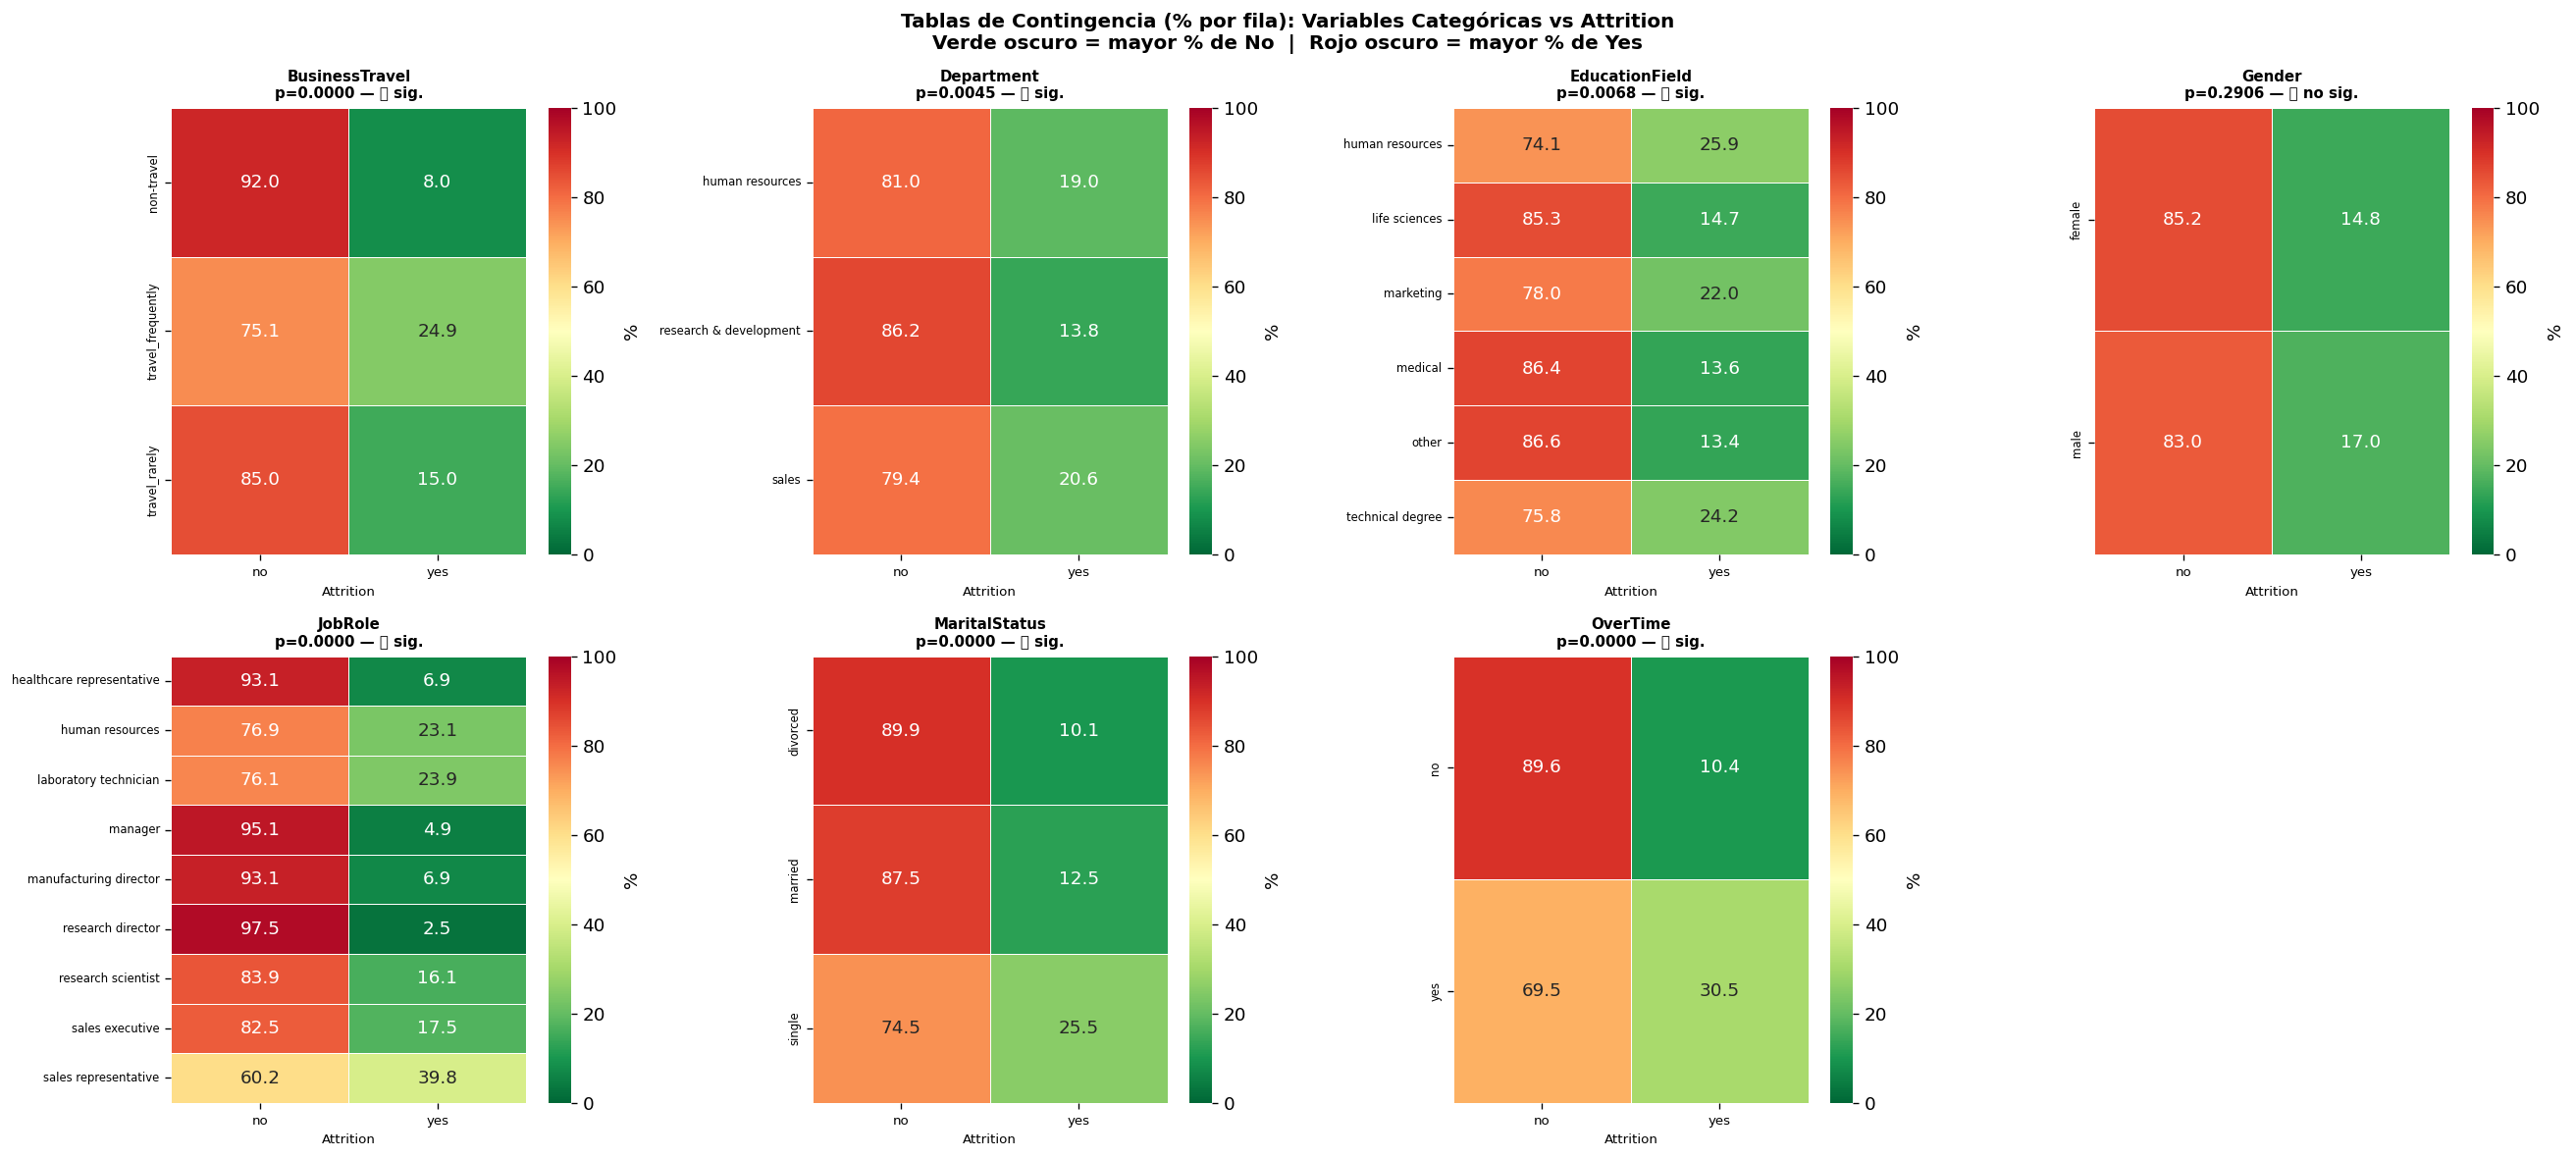

In [4]:
n = len(CAT_VARS)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for i, var in enumerate(CAT_VARS):
    ax = axes[i]
    tabla = pd.crosstab(df[var], df['Attrition'], normalize='index') * 100
    sns.heatmap(tabla, annot=True, fmt='.1f', cmap='RdYlGn_r',
                linewidths=0.5, ax=ax, cbar_kws={'label': '%'},
                vmin=0, vmax=100)
    p = chi2_df.loc[var, 'p-valor']
    sig = '✅ sig.' if chi2_df.loc[var, 'Rechaza H₀'] else '❌ no sig.'
    ax.set_title(f'{var}\np={p:.4f} — {sig}', fontweight='bold', fontsize=9)
    ax.set_xlabel('Attrition', fontsize=8)
    ax.set_ylabel('')
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(axis='y', labelsize=7)

for j in range(n, len(axes)):
    axes[j].set_visible(False)

fig.suptitle('Tablas de Contingencia (% por fila): Variables Categóricas vs Attrition\n'
             'Verde oscuro = mayor % de No  |  Rojo oscuro = mayor % de Yes',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('chi2_heatmaps.png', bbox_inches='tight')
plt.show()

---
## 3. Variables Categóricas — Mutual Information

**H₀:** La variable X no comparte información con Attrition (MI = 0).  
**H₁:** Existe información compartida entre la variable X y Attrition (MI > 0).

**¿Por qué Mutual Information?**  
Chi-cuadrado indica *si* existe dependencia, pero no su magnitud.
Mutual Information cuantifica *cuánta* información aporta cada variable sobre
Attrition, sin asumir linealidad ni distribución específica. Permite **rankear**
las variables por relevancia predictiva. Se interpreta como la reducción de
incertidumbre de Attrition al conocer X.

> **Nota:** MI no tiene un p-valor estándar como las pruebas paramétricas.
> Se reporta el valor absoluto y se interpreta por magnitud:
> MI = 0 → independencia | MI > 0 → dependencia (mayor valor = mayor asociación).

In [5]:
le = LabelEncoder()
attrition_enc = le.fit_transform(df['Attrition'])

print("=" * 70)
print("  MUTUAL INFORMATION — Variables Categóricas vs Attrition")
print("  Interpretación: MI > 0 indica dependencia; mayor MI = mayor asociación")
print("=" * 70)
print()

mi_results = []
for var in CAT_VARS:
    var_enc = le.fit_transform(df[var].astype(str))
    mi = mutual_info_score(var_enc, attrition_enc)
    mi_results.append({'Variable': var, 'Mutual Information': round(mi, 5)})
    flag = '📌 MI significativo' if mi > 0.01 else '  MI bajo (poca información compartida)'
    print(f"  {var:<30}  MI = {mi:.5f}   {flag}")

mi_df = pd.DataFrame(mi_results).sort_values('Mutual Information', ascending=False)
mi_df = mi_df.set_index('Variable')

  MUTUAL INFORMATION — Variables Categóricas vs Attrition
  Interpretación: MI > 0 indica dependencia; mayor MI = mayor asociación

  BusinessTravel                  MI = 0.00808     MI bajo (poca información compartida)
  Department                      MI = 0.00357     MI bajo (poca información compartida)
  EducationField                  MI = 0.00507     MI bajo (poca información compartida)
  Gender                          MI = 0.00044     MI bajo (poca información compartida)
  JobRole                         MI = 0.03024   📌 MI significativo
  MaritalStatus                   MI = 0.01497   📌 MI significativo
  OverTime                        MI = 0.02769   📌 MI significativo


### 3.1 Gráfica: ranking de Mutual Information

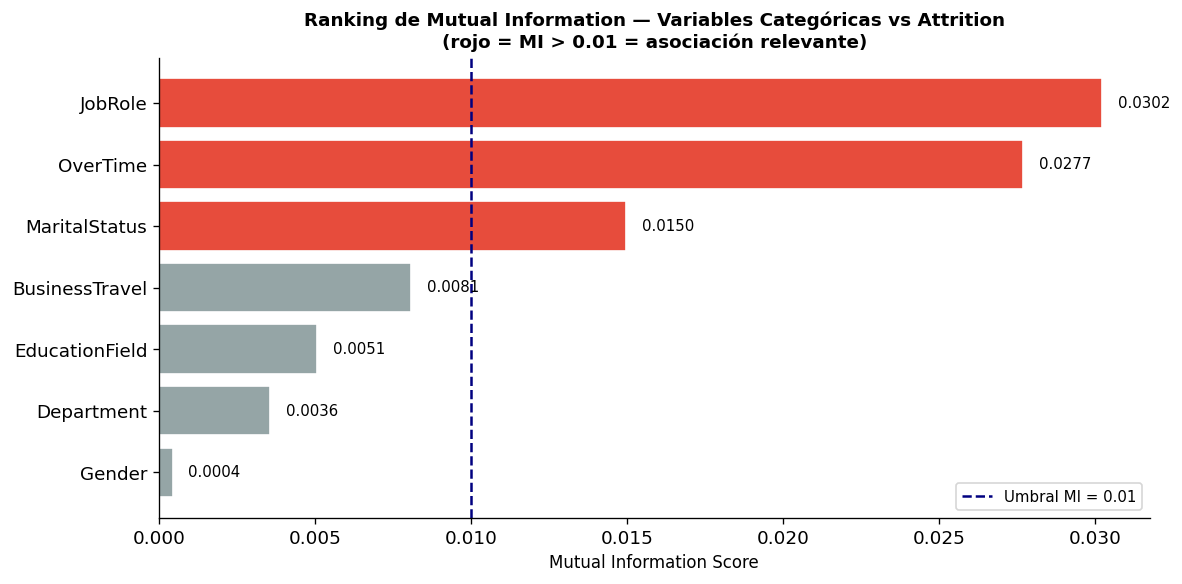

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sorted_mi = mi_df.sort_values('Mutual Information')
colors = ['#e74c3c' if v > 0.01 else '#95a5a6' for v in sorted_mi['Mutual Information']]
bars = ax.barh(sorted_mi.index, sorted_mi['Mutual Information'],
               color=colors, edgecolor='white')
for bar, val in zip(bars, sorted_mi['Mutual Information']):
    ax.text(bar.get_width() + 0.0005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', fontsize=9)
ax.axvline(0.01, color='navy', linestyle='--', lw=1.5,
           label='Umbral MI = 0.01')
ax.set_xlabel('Mutual Information Score', fontsize=10)
ax.set_title('Ranking de Mutual Information — Variables Categóricas vs Attrition\n'
             '(rojo = MI > 0.01 = asociación relevante)', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('mutual_information_cat.png', bbox_inches='tight')
plt.show()

---
## 4. Variables Numéricas Continuas — Correlación de Pearson

**H₀:** No existe correlación lineal entre la variable X y Attrition (ρ = 0).  
**H₁:** Existe correlación lineal significativa entre la variable X y Attrition (ρ ≠ 0).

**¿Por qué Pearson?**  
Mide la fuerza y dirección de la relación *lineal* entre dos variables cuantitativas.
Se aplica sobre la versión binaria de Attrition (Yes=1, No=0). 

**Interpretación del coeficiente r:**  
|r| < 0.10 = despreciable | 0.10–0.30 = débil | 0.30–0.50 = moderado | > 0.50 = fuerte

In [7]:
print("=" * 80)
print("  CORRELACIÓN DE PEARSON — Variables Numéricas Continuas vs Attrition_bin")
print(f"  H₀: ρ = 0  |  H₁: ρ ≠ 0  |  α = {ALPHA}")
print("=" * 80)
print()

pearson_results = []
for var in NUM_CONT:
    r, pval = pearsonr(df[var], df['Attrition_bin'])
    rechaza = pval < ALPHA
    fuerza = ('fuerte' if abs(r)>0.5 else 'moderada' if abs(r)>0.3
              else 'débil' if abs(r)>0.1 else 'despreciable')
    reporte(var, 'Pearson', r, pval, rechaza, f'  r={r:.4f} ({fuerza})')
    pearson_results.append({'Variable': var, 'r': round(r,4),
                            'p-valor': round(pval,6), 'Rechaza H₀': rechaza,
                            'Fuerza': fuerza})

pearson_df = pd.DataFrame(pearson_results).set_index('Variable')
print()
print(pearson_df.to_string())

  CORRELACIÓN DE PEARSON — Variables Numéricas Continuas vs Attrition_bin
  H₀: ρ = 0  |  H₁: ρ ≠ 0  |  α = 0.05

**Age                            [Pearson]  stat=   -0.1592  p=0.000000  → ✅ SE RECHAZA H₀  r=-0.1592 (débil)
**DailyRate                      [Pearson]  stat=   -0.0567  p=0.029858  → ✅ SE RECHAZA H₀  r=-0.0567 (despreciable)
**DistanceFromHome               [Pearson]  stat=    0.0779  p=0.002793  → ✅ SE RECHAZA H₀  r=0.0779 (despreciable)
  HourlyRate                     [Pearson]  stat=   -0.0068  p=0.793135  → ❌ NO se rechaza H₀  r=-0.0068 (despreciable)
**MonthlyIncome                  [Pearson]  stat=   -0.1598  p=0.000000  → ✅ SE RECHAZA H₀  r=-0.1598 (débil)
  MonthlyRate                    [Pearson]  stat=    0.0152  p=0.561124  → ❌ NO se rechaza H₀  r=0.0152 (despreciable)
  PercentSalaryHike              [Pearson]  stat=   -0.0135  p=0.605613  → ❌ NO se rechaza H₀  r=-0.0135 (despreciable)
**TotalWorkingYears              [Pearson]  stat=   -0.1711  p=0.000000  →

### 4.1 Gráfica: barras de correlación de Pearson con bandas de fuerza

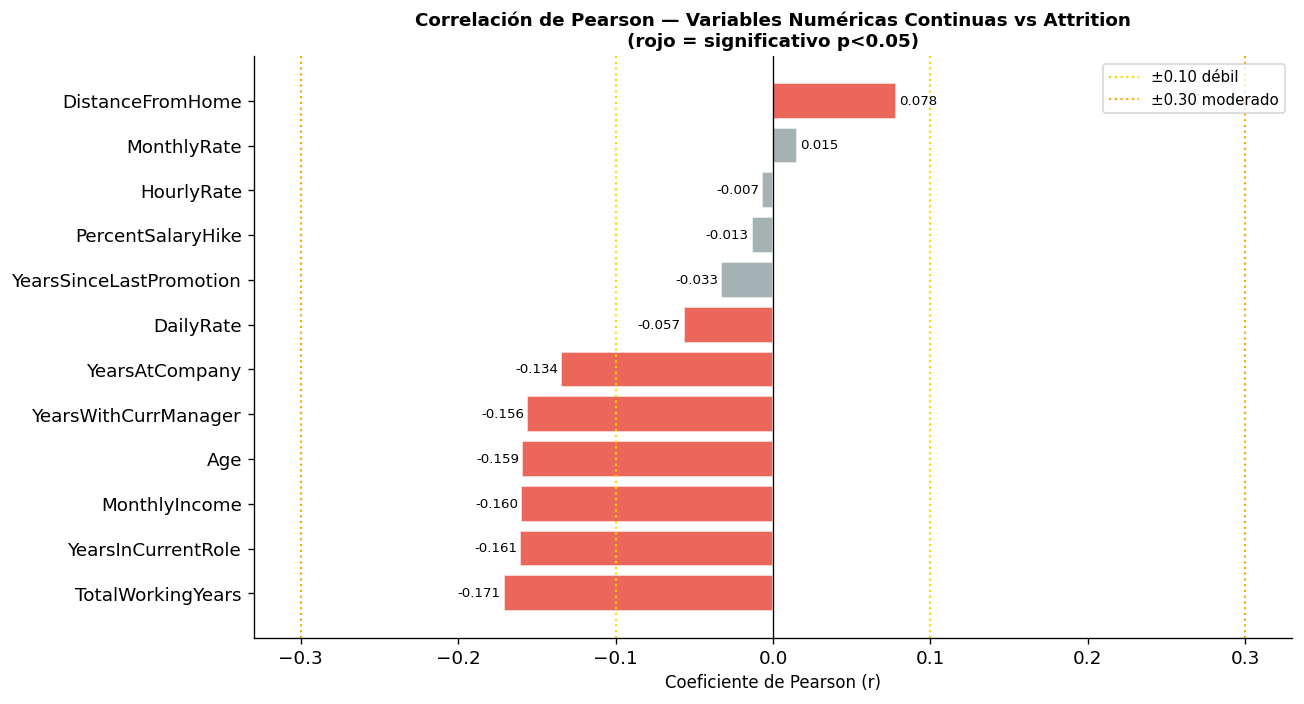

In [8]:
fig, ax = plt.subplots(figsize=(11, 6))
sorted_p = pearson_df.sort_values('r')
colors = ['#e74c3c' if p < ALPHA else '#95a5a6'
          for p in sorted_p['p-valor']]
bars = ax.barh(sorted_p.index, sorted_p['r'], color=colors,
               edgecolor='white', alpha=0.85)
ax.axvline(0,     color='black', lw=0.8)
ax.axvline( 0.10, color='gold',  linestyle=':', lw=1.3, label='±0.10 débil')
ax.axvline(-0.10, color='gold',  linestyle=':', lw=1.3)
ax.axvline( 0.30, color='orange',linestyle=':', lw=1.3, label='±0.30 moderado')
ax.axvline(-0.30, color='orange',linestyle=':', lw=1.3)
for bar, val in zip(bars, sorted_p['r']):
    xpos = bar.get_width() + (0.002 if val >= 0 else -0.002)
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=8)
ax.set_xlabel('Coeficiente de Pearson (r)', fontsize=10)
ax.set_title('Correlación de Pearson — Variables Numéricas Continuas vs Attrition\n'
             '(rojo = significativo p<0.05)', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('pearson_correlacion.png', bbox_inches='tight')
plt.show()

---
## 5. Variables Numéricas — Correlación de Spearman

**H₀:** No existe correlación monótona entre la variable X y Attrition (ρₛ = 0).  
**H₁:** Existe correlación monótona significativa (ρₛ ≠ 0).


**Se aplica a:** Numéricas continuas + Numéricas ordinales.

In [9]:
TODAS_NUM = NUM_CONT + NUM_ORD

print("=" * 80)
print("  CORRELACIÓN DE SPEARMAN — Variables Numéricas vs Attrition_bin")
print(f"  H₀: ρₛ = 0  |  H₁: ρₛ ≠ 0  |  α = {ALPHA}")
print("=" * 80)
print()

spearman_results = []
for var in TODAS_NUM:
    rs, pval = spearmanr(df[var], df['Attrition_bin'])
    rechaza = pval < ALPHA
    fuerza = ('fuerte' if abs(rs)>0.5 else 'moderada' if abs(rs)>0.3
              else 'débil' if abs(rs)>0.1 else 'despreciable')
    reporte(var, 'Spearman', rs, pval, rechaza, f'  ρₛ={rs:.4f} ({fuerza})')
    spearman_results.append({'Variable': var, 'ρₛ': round(rs,4),
                             'p-valor': round(pval,6), 'Rechaza H₀': rechaza,
                             'Fuerza': fuerza})

spearman_df = pd.DataFrame(spearman_results).set_index('Variable')
print()
print(spearman_df.to_string())

  CORRELACIÓN DE SPEARMAN — Variables Numéricas vs Attrition_bin
  H₀: ρₛ = 0  |  H₁: ρₛ ≠ 0  |  α = 0.05

**Age                            [Spearman]  stat=   -0.1712  p=0.000000  → ✅ SE RECHAZA H₀  ρₛ=-0.1712 (débil)
**DailyRate                      [Spearman]  stat=   -0.0570  p=0.028950  → ✅ SE RECHAZA H₀  ρₛ=-0.0570 (despreciable)
**DistanceFromHome               [Spearman]  stat=    0.0792  p=0.002361  → ✅ SE RECHAZA H₀  ρₛ=0.0792 (despreciable)
  HourlyRate                     [Spearman]  stat=   -0.0067  p=0.797665  → ❌ NO se rechaza H₀  ρₛ=-0.0067 (despreciable)
**MonthlyIncome                  [Spearman]  stat=   -0.1983  p=0.000000  → ✅ SE RECHAZA H₀  ρₛ=-0.1983 (débil)
  MonthlyRate                    [Spearman]  stat=    0.0153  p=0.558870  → ❌ NO se rechaza H₀  ρₛ=0.0153 (despreciable)
  PercentSalaryHike              [Spearman]  stat=   -0.0236  p=0.365648  → ❌ NO se rechaza H₀  ρₛ=-0.0236 (despreciable)
**TotalWorkingYears              [Spearman]  stat=   -0.1990  p=0.0

### 5.1 Gráfica: comparación Pearson vs Spearman (continuas)

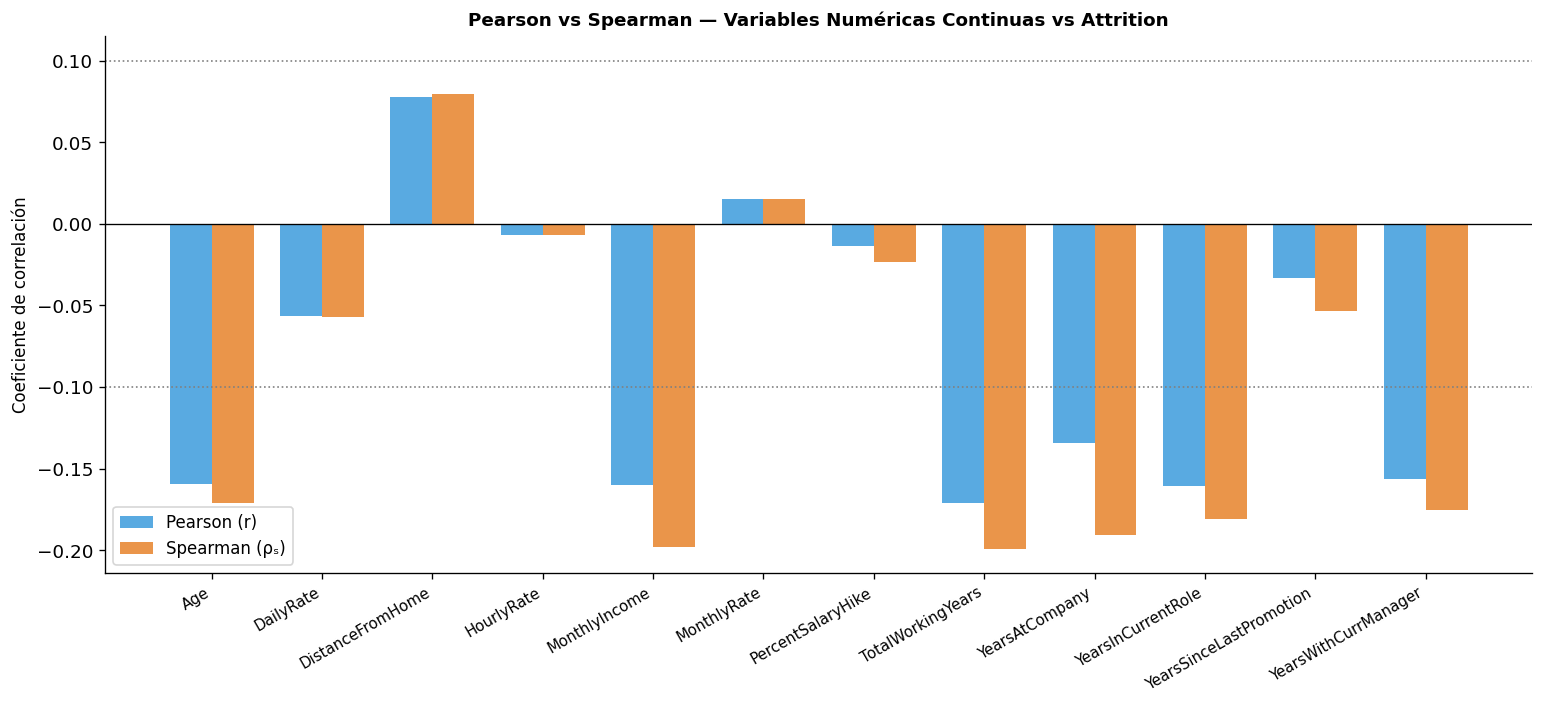

In [10]:
vars_comun = [v for v in NUM_CONT if v in pearson_df.index and v in spearman_df.index]
p_r   = pearson_df.loc[vars_comun, 'r']
s_rho = spearman_df.loc[vars_comun, 'ρₛ']

fig, ax = plt.subplots(figsize=(13, 6))
x = np.arange(len(vars_comun))
w = 0.38
ax.bar(x - w/2, p_r.values,   w, label='Pearson (r)',   color='#3498db', alpha=0.82)
ax.bar(x + w/2, s_rho.values, w, label='Spearman (ρₛ)', color='#e67e22', alpha=0.82)
ax.axhline(0, color='black', lw=0.8)
ax.axhline( 0.1, color='gray', linestyle=':', lw=1)
ax.axhline(-0.1, color='gray', linestyle=':', lw=1)
ax.set_xticks(x)
ax.set_xticklabels(vars_comun, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Coeficiente de correlación', fontsize=10)
ax.set_title('Pearson vs Spearman — Variables Numéricas Continuas vs Attrition',
             fontweight='bold', fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig('pearson_vs_spearman.png', bbox_inches='tight')
plt.show()

---
## 6. Variables Numéricas Ordinales — Correlación de Kendall

**H₀:** No existe concordancia entre la variable ordinal X y Attrition (τ = 0).  
**H₁:** Existe concordancia significativa entre X y Attrition (τ ≠ 0).

**¿Por qué Kendall para variables ordinales?**  
Las variables ordinales del dataset (Education, JobLevel, JobSatisfaction, etc.)
tienen pocos niveles distintos (2–5), lo que genera muchos *empates* en los rangos.
Kendall maneja mejor los empates que Spearman y produce estimaciones más conservadoras
y estables.

In [11]:
print("=" * 80)
print("  CORRELACIÓN DE KENDALL — Variables Ordinales vs Attrition_bin")
print(f"  H₀: τ = 0  |  H₁: τ ≠ 0  |  α = {ALPHA}")
print("=" * 80)
print()

kendall_results = []
for var in NUM_ORD:
    tau, pval = kendalltau(df[var], df['Attrition_bin'])
    rechaza = pval < ALPHA
    fuerza = ('fuerte' if abs(tau)>0.5 else 'moderada' if abs(tau)>0.3
              else 'débil' if abs(tau)>0.1 else 'despreciable')
    reporte(var, 'Kendall', tau, pval, rechaza, f'  τ={tau:.4f} ({fuerza})')
    kendall_results.append({'Variable': var, 'τ': round(tau,4),
                            'p-valor': round(pval,6), 'Rechaza H₀': rechaza,
                            'Fuerza': fuerza})

kendall_df = pd.DataFrame(kendall_results).set_index('Variable')
print()
print(kendall_df.to_string())

  CORRELACIÓN DE KENDALL — Variables Ordinales vs Attrition_bin
  H₀: τ = 0  |  H₁: τ ≠ 0  |  α = 0.05

  Education                      [Kendall]  stat=   -0.0278  p=0.244795  → ❌ NO se rechaza H₀  τ=-0.0278 (despreciable)
**EnvironmentSatisfaction        [Kendall]  stat=   -0.0884  p=0.000217  → ✅ SE RECHAZA H₀  τ=-0.0884 (despreciable)
**JobInvolvement                 [Kendall]  stat=   -0.1135  p=0.000005  → ✅ SE RECHAZA H₀  τ=-0.1135 (débil)
**JobLevel                       [Kendall]  stat=   -0.1758  p=0.000000  → ✅ SE RECHAZA H₀  τ=-0.1758 (débil)
**JobSatisfaction                [Kendall]  stat=   -0.0943  p=0.000080  → ✅ SE RECHAZA H₀  τ=-0.0943 (despreciable)
  NumCompaniesWorked             [Kendall]  stat=    0.0269  p=0.242331  → ❌ NO se rechaza H₀  τ=0.0269 (despreciable)
  PerformanceRating              [Kendall]  stat=    0.0029  p=0.911839  → ❌ NO se rechaza H₀  τ=0.0029 (despreciable)
  RelationshipSatisfaction       [Kendall]  stat=   -0.0391  p=0.102007  → ❌ NO se r

### 6.1 Gráfica: τ de Kendall por variable ordinal

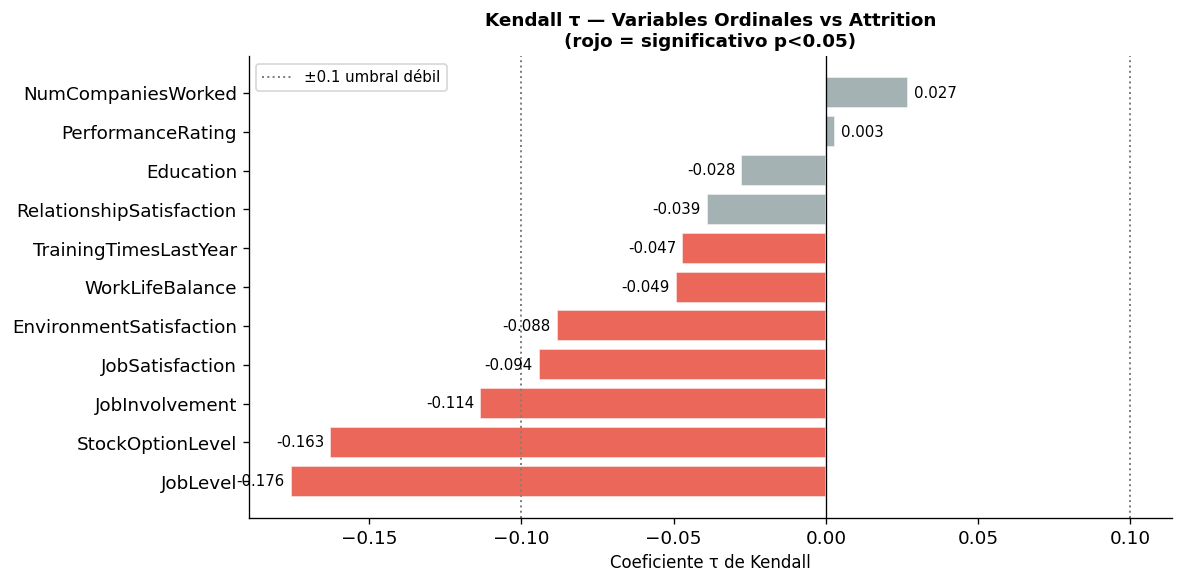

In [12]:
fig, ax = plt.subplots(figsize=(10, 5))
kdf = kendall_df.sort_values('τ')
colors = ['#e74c3c' if p < ALPHA else '#95a5a6' for p in kdf['p-valor']]
bars = ax.barh(kdf.index, kdf['τ'], color=colors, edgecolor='white', alpha=0.85)
ax.axvline(0, color='black', lw=0.8)
ax.axvline( 0.1, color='gray', linestyle=':', lw=1.2, label='±0.1 umbral débil')
ax.axvline(-0.1, color='gray', linestyle=':', lw=1.2)
for bar, val in zip(bars, kdf['τ']):
    xpos = bar.get_width() + (0.002 if val >= 0 else -0.002)
    ha = 'left' if val >= 0 else 'right'
    ax.text(xpos, bar.get_y()+bar.get_height()/2,
            f'{val:.3f}', va='center', ha=ha, fontsize=9)
ax.set_xlabel('Coeficiente τ de Kendall', fontsize=10)
ax.set_title('Kendall τ — Variables Ordinales vs Attrition\n'
             '(rojo = significativo p<0.05)', fontweight='bold', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('kendall_ordinales.png', bbox_inches='tight')
plt.show()

---
## 7. Variables Mixtas — ANOVA y Kruskal-Wallis

**H₀:** La distribución de la variable numérica X es igual en los grupos Attrition=Yes y Attrition=No.  
**H₁:** Existe diferencia significativa en X entre los grupos Yes y No.

**¿Cuándo usar ANOVA vs Kruskal-Wallis?**

Se verifica normalidad con **Shapiro-Wilk** en cada grupo:
- Si ambos grupos son aproximadamente normales → **ANOVA** (más potente).
- Si algún grupo no es normal → **Kruskal-Wallis** (no paramétrica, usa rangos).



In [14]:
print("=" * 80)
print("  ANOVA y KRUSKAL-WALLIS — Variables Numéricas vs grupos de Attrition")
print(f"  H₀: misma distribución en Yes y No  |  α = {ALPHA}")
print("=" * 80)
print()

grupo_yes = df[df['Attrition_bin'] == 1]
grupo_no  = df[df['Attrition_bin'] == 0]

anova_results = []
for var in NUM_CONT + NUM_ORD:
    g1 = grupo_yes[var].dropna().values
    g2 = grupo_no[var].dropna().values

    # Shapiro-Wilk (muestra máx 5000)
    sw1 = shapiro(g1[:5000])[1]
    sw2 = shapiro(g2[:5000])[1]
    normal = (sw1 >= ALPHA) and (sw2 >= ALPHA)

    # ANOVA
    F, p_anova = f_oneway(g1, g2)
    # Kruskal-Wallis
    H, p_kw    = kruskal(g1, g2)

    prueba_rec = 'ANOVA' if normal else 'Kruskal'
    p_rec      = p_anova if normal else p_kw
    rechaza    = p_rec < ALPHA

    nota = f'  (Shapiro Yes p={sw1:.3f} / No p={sw2:.3f}) → usa {prueba_rec}'
    reporte(var, prueba_rec, F if normal else H, p_rec, rechaza, nota)

    anova_results.append({
        'Variable': var,
        'F (ANOVA)': round(F, 4), 'p ANOVA': round(p_anova, 6),
        'H (KW)': round(H, 4),    'p KW': round(p_kw, 6),
        'Normal': normal, 'Prueba rec.': prueba_rec,
        'p recomendada': round(p_rec, 6), 'Rechaza H₀': rechaza
    })

anova_df = pd.DataFrame(anova_results).set_index('Variable')
print()
print(anova_df[['F (ANOVA)','p ANOVA','H (KW)','p KW',
                'Normal','Prueba rec.','Rechaza H₀']].to_string())

  ANOVA y KRUSKAL-WALLIS — Variables Numéricas vs grupos de Attrition
  H₀: misma distribución en Yes y No  |  α = 0.05

**Age                            [Kruskal]  stat=   43.0627  p=0.000000  → ✅ SE RECHAZA H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
**DailyRate                      [Kruskal]  stat=    4.7677  p=0.028998  → ✅ SE RECHAZA H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
**DistanceFromHome               [Kruskal]  stat=    9.2257  p=0.002386  → ✅ SE RECHAZA H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
  HourlyRate                     [Kruskal]  stat=    0.0658  p=0.797566  → ❌ NO se rechaza H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
**MonthlyIncome                  [Kruskal]  stat=   57.7682  p=0.000000  → ✅ SE RECHAZA H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
  MonthlyRate                    [Kruskal]  stat=    0.3420  p=0.558692  → ❌ NO se rechaza H₀  (Shapiro Yes p=0.000 / No p=0.000) → usa Kruskal
  PercentSalaryHike        

### 7.1 Boxplots de las variables significativas por grupo Attrition

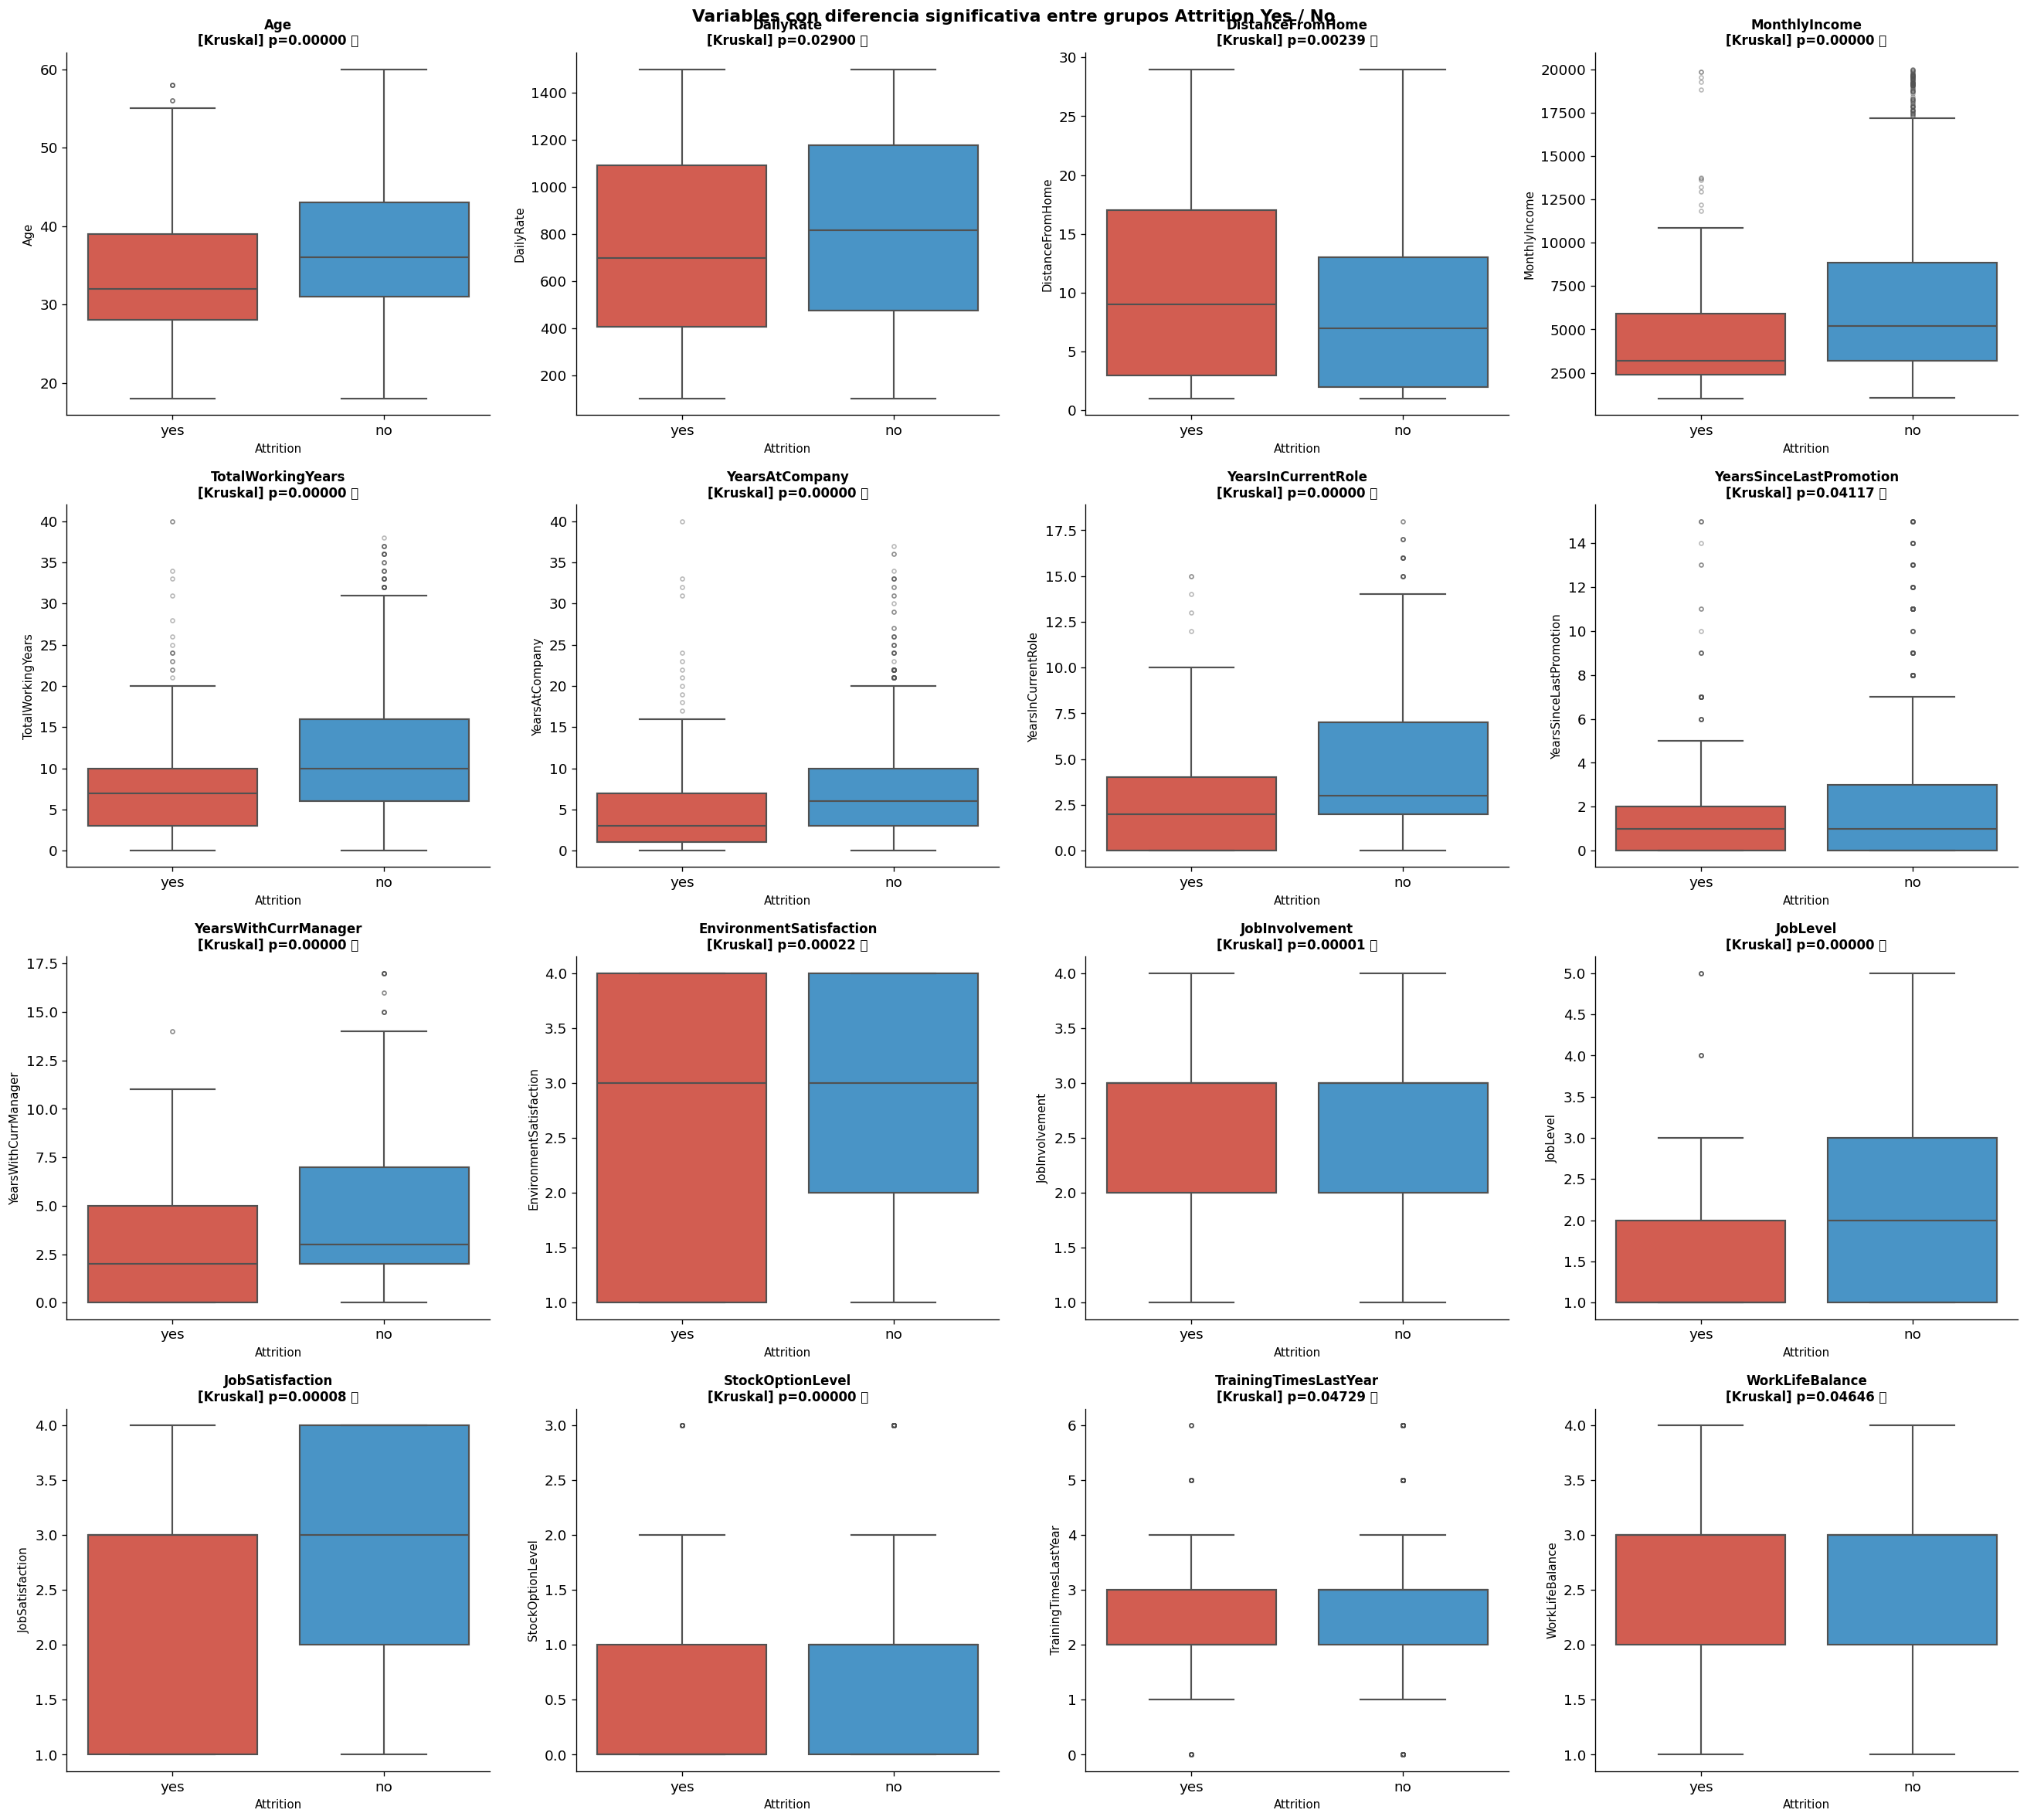

Variables significativas (16): ['Age', 'DailyRate', 'DistanceFromHome', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'StockOptionLevel', 'TrainingTimesLastYear', 'WorkLifeBalance']


In [16]:
sig_vars = anova_df[anova_df['Rechaza H₀']].index.tolist()

if sig_vars:
    ncols = 4
    nrows = int(np.ceil(len(sig_vars) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(22, nrows * 5))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes.flatten()

    palette = {'yes': '#e74c3c', 'no': '#3498db'}
    for i, var in enumerate(sig_vars):
        ax = axes[i]
        sns.boxplot(data=df, x='Attrition', y=var,
                    palette=palette, order=['yes','no'], ax=ax,
                    linewidth=1.3,
                    flierprops=dict(marker='o', markersize=3, alpha=0.4))
        p_val = anova_df.loc[var, 'p recomendada']
        prueba = anova_df.loc[var, 'Prueba rec.']
        ax.set_title(f'{var}\n[{prueba}] p={p_val:.5f} ✅',
                     fontweight='bold', fontsize=10)
        ax.set_xlabel('Attrition', fontsize=9)
        ax.set_ylabel(var, fontsize=9)

    for j in range(len(sig_vars), len(axes)):
        axes[j].set_visible(False)

    fig.suptitle('Variables con diferencia significativa entre grupos Attrition Yes / No',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('boxplots_significativos.png', bbox_inches='tight')
    plt.show()
    print(f"Variables significativas ({len(sig_vars)}): {sig_vars}")
else:
    print("No se encontraron variables significativas con ANOVA/KW.")

### 8.1 Gráfica: mapa de calor del resumen global

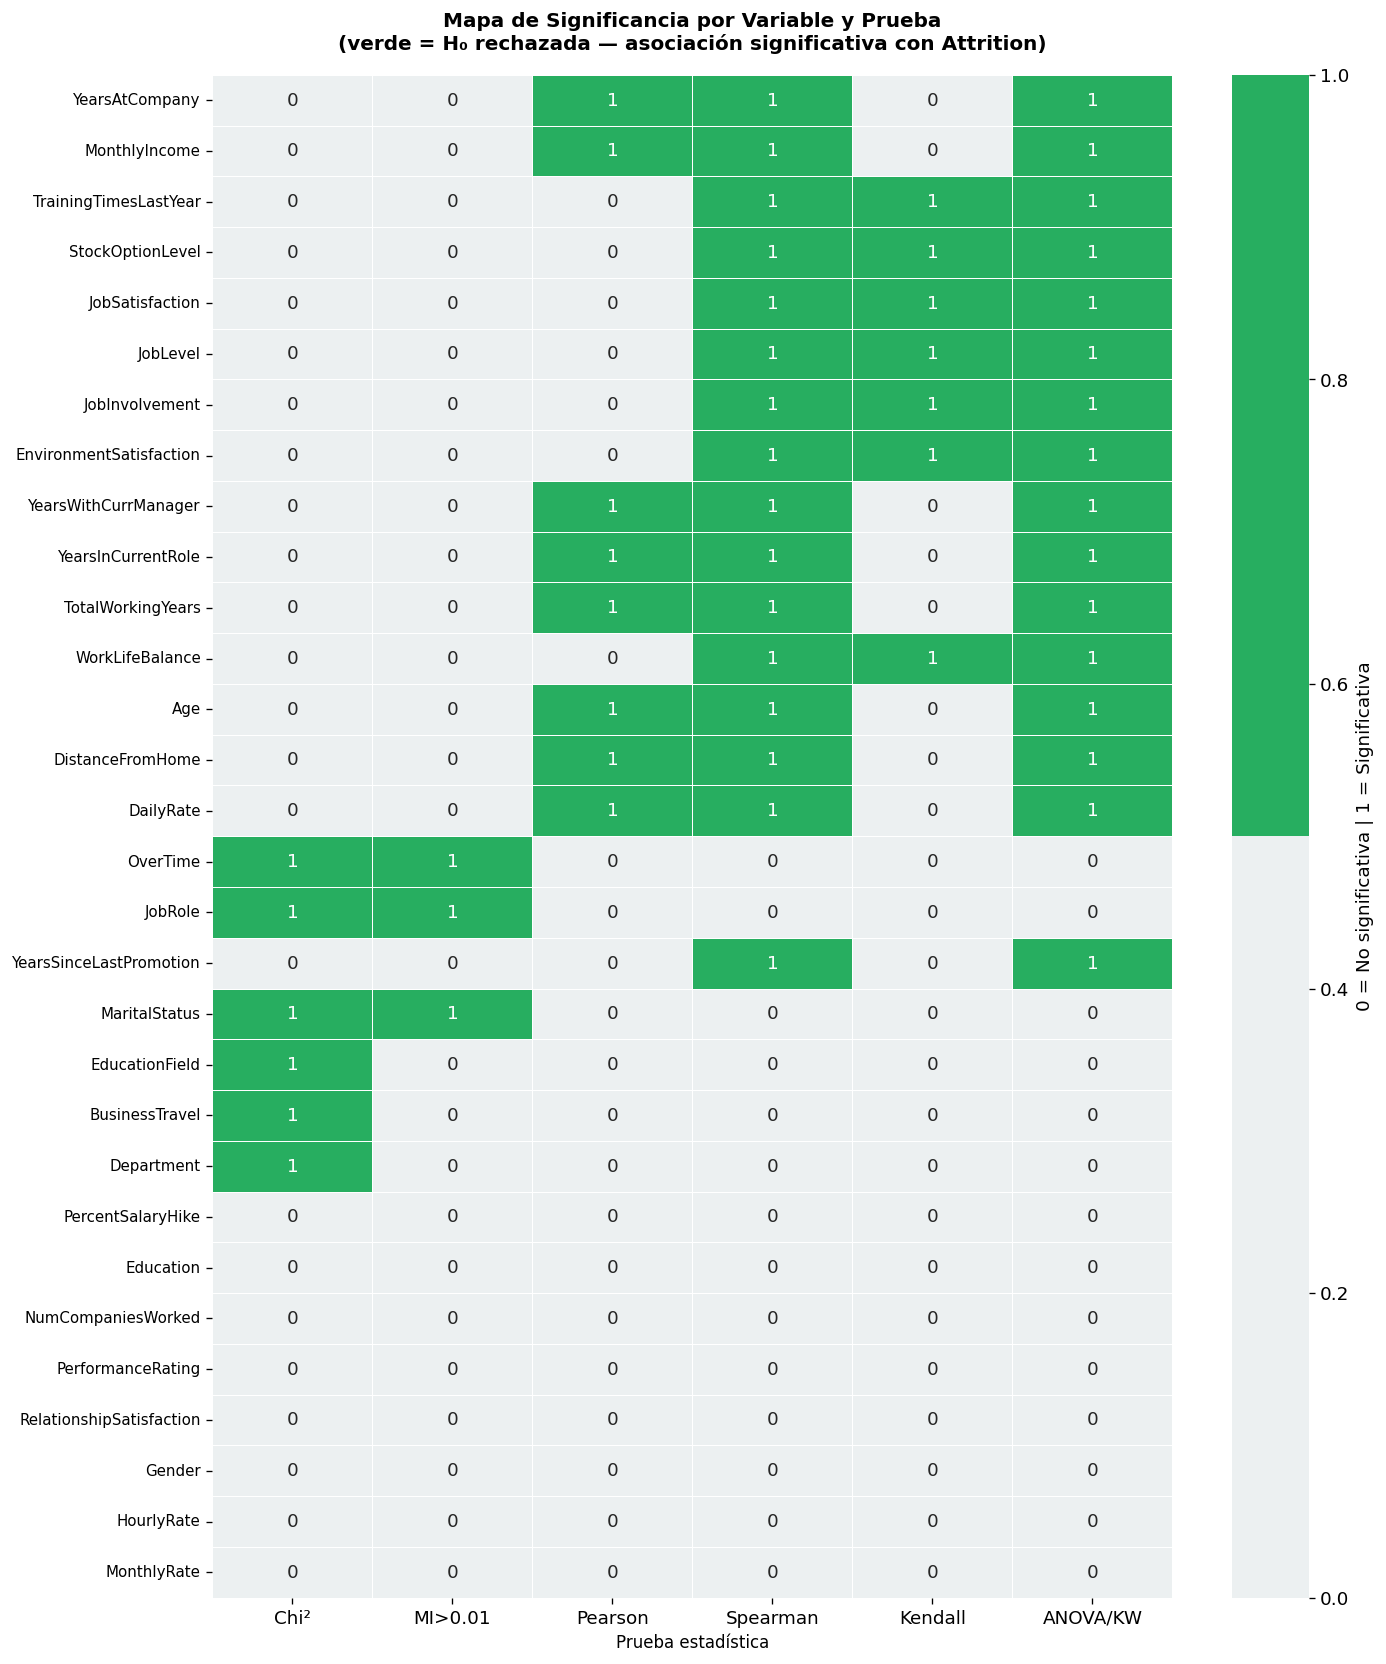

In [17]:
# Matriz de significancia: 1 = sig, 0 = no sig por prueba
sig_matrix_data = {}

for var in CAT_VARS:
    sig_matrix_data[var] = {
        'Chi²': int(chi2_df.loc[var,'Rechaza H₀']),
        'MI>0.01': int(mi_df.loc[var,'Mutual Information'] > 0.01) if var in mi_df.index else 0,
        'Pearson': 0, 'Spearman': 0, 'Kendall': 0, 'ANOVA/KW': 0
    }

for var in NUM_CONT:
    sig_matrix_data[var] = {
        'Chi²': 0, 'MI>0.01': 0,
        'Pearson':   int(pearson_df.loc[var,'Rechaza H₀'])  if var in pearson_df.index  else 0,
        'Spearman':  int(spearman_df.loc[var,'Rechaza H₀']) if var in spearman_df.index else 0,
        'Kendall': 0,
        'ANOVA/KW':  int(anova_df.loc[var,'Rechaza H₀'])    if var in anova_df.index    else 0,
    }

for var in NUM_ORD:
    sig_matrix_data[var] = {
        'Chi²': 0, 'MI>0.01': 0,
        'Pearson': 0,
        'Spearman':  int(spearman_df.loc[var,'Rechaza H₀']) if var in spearman_df.index else 0,
        'Kendall':   int(kendall_df.loc[var,'Rechaza H₀'])  if var in kendall_df.index  else 0,
        'ANOVA/KW':  int(anova_df.loc[var,'Rechaza H₀'])    if var in anova_df.index    else 0,
    }

sig_matrix = pd.DataFrame(sig_matrix_data).T
# Ordenar por total de significancias
sig_matrix['_total'] = sig_matrix.sum(axis=1)
sig_matrix = sig_matrix.sort_values('_total', ascending=False).drop(columns='_total')

fig, ax = plt.subplots(figsize=(12, 14))
sns.heatmap(sig_matrix, annot=True, fmt='d', cmap=['#ecf0f1','#27ae60'],
            linewidths=0.5, linecolor='white', ax=ax,
            cbar_kws={'label': '0 = No significativa | 1 = Significativa'},
            vmin=0, vmax=1)
ax.set_title('Mapa de Significancia por Variable y Prueba\n'
             '(verde = H₀ rechazada — asociación significativa con Attrition)',
             fontweight='bold', fontsize=12, pad=15)
ax.set_xlabel('Prueba estadística', fontsize=10)
ax.tick_params(axis='y', labelsize=9)
plt.tight_layout()
plt.savefig('resumen_significancia_global.png', bbox_inches='tight')
plt.show()